# GAT (Graph Attention Network) Fraud Prediction
This notebook implements a GAT-style Link Prediction model with Multi-Head Attention using PyTorch.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Load Data & Preprocessing

In [2]:
df = pd.read_csv("online_retail_indian_augmented.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Is_Return,Total_Price,City,State,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base,Multi_Size_Order
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,0,83.4,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.210705,0.184411,85048.0,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.296208,0.184411,79323.0,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.332672,0.184411,79323.0,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,0,100.8,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.101050,0.184411,22041.0,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,0,30.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.147180,0.184411,21232.0,True


In [3]:
conditions = (
    (df['Is_Return'] == 1) & 
    ((df['User_Global_Return_Rate'] > 0.7) | (df['Multi_Size_Order'] == True))
)
df['Is_Fraud'] = np.where(conditions, 1, 0)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Is_Return,Total_Price,City,State,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base,Multi_Size_Order,Is_Fraud
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,0,83.4,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.210705,0.184411,85048.0,True,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.296208,0.184411,79323.0,True,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.332672,0.184411,79323.0,True,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,0,100.8,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.101050,0.184411,22041.0,True,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,0,30.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.147180,0.184411,21232.0,True,0


In [4]:
user_ids = df['Customer ID'].unique()
product_ids = df['StockCode'].unique()
user_to_idx = {u: i for i, u in enumerate(user_ids)}
product_to_idx = {p: i for i, p in enumerate(product_ids)}

In [5]:
df['User_Idx'] = df['Customer ID'].map(user_to_idx)
df['Item_Idx'] = df['StockCode'].map(product_to_idx)
df = df.dropna(subset=['User_Idx', 'Item_Idx'])
df['User_Idx'] = df['User_Idx'].astype(int)
df['Item_Idx'] = df['Item_Idx'].astype(int)

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Is_Return,Total_Price,City,State,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base,Multi_Size_Order,Is_Fraud,User_Idx,Item_Idx
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,0,83.4,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.210705,0.184411,85048.0,True,0,0,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.296208,0.184411,79323.0,True,0,0,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.332672,0.184411,79323.0,True,0,0,2
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,0,100.8,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.101050,0.184411,22041.0,True,0,0,3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,0,30.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.147180,0.184411,21232.0,True,0,0,4


In [7]:
# making Features
X_feat = df[['Total_Price', 'Product_Return_Rate']].fillna(0).values
X_feat = (X_feat - X_feat.mean(axis=0)) / (X_feat.std(axis=0) + 1e-6) 

user_tensor = torch.tensor(df['User_Idx'].values, dtype=torch.long)
item_tensor = torch.tensor(df['Item_Idx'].values, dtype=torch.long)
feat_tensor = torch.tensor(X_feat, dtype=torch.float)
y_tensor = torch.tensor(df['Is_Fraud'].values, dtype=torch.float).view(-1, 1)

train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42, stratify=df['Is_Fraud'])

## 3. Training Loop

In [8]:
from GAT import SimpleGATLinkPredictor

In [9]:
print("Training GAT-style Model...")
model = SimpleGATLinkPredictor(len(user_ids), len(product_ids))
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.BCELoss()

epochs = 10
batch_size = 1024
loss_history = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(len(train_idx))
    epoch_loss = 0
    
    for i in range(0, len(train_idx), batch_size):
        indices = train_idx[permutation[i:i+batch_size]]
        u_b = user_tensor[indices]
        i_b = item_tensor[indices]
        f_b = feat_tensor[indices]
        y_b = y_tensor[indices]
        
        optimizer.zero_grad()
        preds = model(u_b, i_b, f_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_idx)*batch_size:.4f}")
    loss_history.append(epoch_loss/len(train_idx)*batch_size)

Training GAT-style Model...
Epoch 1/10, Loss: 0.2121
Epoch 2/10, Loss: 0.2117
Epoch 3/10, Loss: 0.2083
Epoch 4/10, Loss: 0.2022
Epoch 5/10, Loss: 0.1981
Epoch 6/10, Loss: 0.1925
Epoch 7/10, Loss: 0.1898
Epoch 8/10, Loss: 0.1865
Epoch 9/10, Loss: 0.1839
Epoch 10/10, Loss: 0.1826


In [10]:
torch.save(model.state_dict(),"gatmodel.pt")

## 4. Visualizations & Evaluation

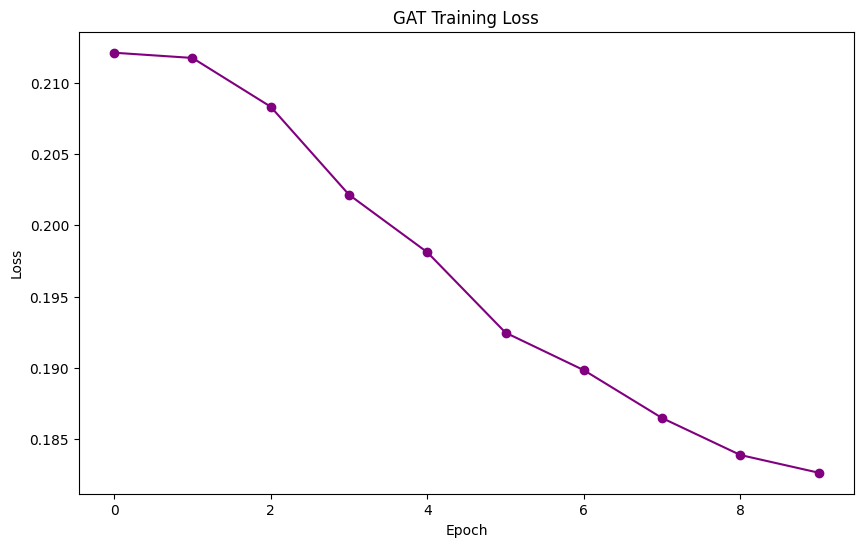

Evaluating GAT...

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97    153248
         1.0       0.53      0.22      0.31      8462

    accuracy                           0.95    161710
   macro avg       0.75      0.60      0.64    161710
weighted avg       0.94      0.95      0.94    161710

ROC AUC Score: 0.8763


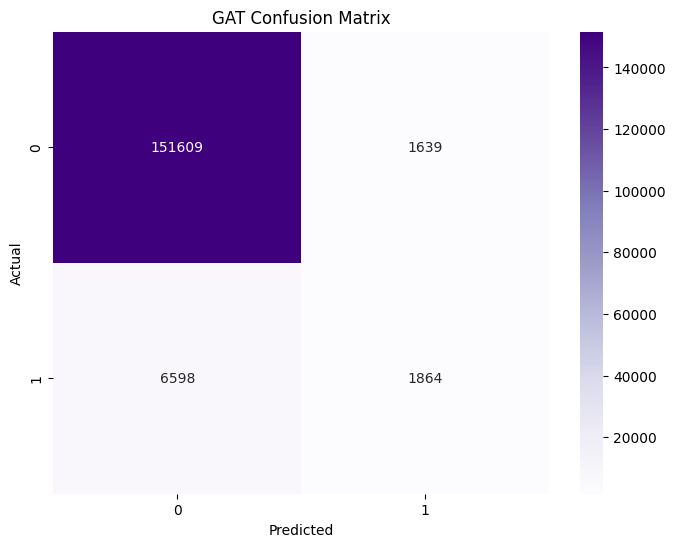

In [11]:
# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(loss_history, marker='o', color='purple')
plt.title('GAT Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Evaluate
print("Evaluating GAT...")
model.eval()
with torch.no_grad():
    u_test = user_tensor[test_idx]
    i_test = item_tensor[test_idx]
    f_test = feat_tensor[test_idx]
    y_test = y_tensor[test_idx]
    
    test_preds = model(u_test, i_test, f_test)
    test_class = (test_preds > 0.5).float()
    
    report = classification_report(y_test.numpy(), test_class.numpy())
    print("\nClassification Report:")
    print(report)
    
    auc = roc_auc_score(y_test.numpy(), test_preds.numpy())
    print(f"ROC AUC Score: {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test.numpy(), test_class.numpy())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title('GAT Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()